In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import ToTensor
import rasterio
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ------------------ Dataset Preparation ------------------
class RemoteSensingDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.startswith("data")])
        self.mask_files = sorted([f for f in os.listdir(mask_dir) if f.startswith("mask")])
        self.transform = transform

        # Mapping kelas ke indeks
        self.class_mapping = {
            11: 0, 13: 1, 15: 2, 21: 3, 22: 4,
            33: 5, 34: 6, 41: 7, 54: 8, 60: 9,
            71: 10, 72: 11, 81: 12, 82: 13
        }

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        with rasterio.open(img_path) as src:
            image = src.read()  # Read as (C, H, W)
        with rasterio.open(mask_path) as src:
            mask = src.read(1)  # Read single channel mask
        
        image = image.astype(np.float32) / 65535.0 #image 16-bit
        mask = mask.astype(np.int64)
        
        # Remap kelas
        remapped_mask = np.zeros_like(mask, dtype=np.int64)
        for old_class, new_class in self.class_mapping.items():
            remapped_mask[mask == old_class] = new_class

        if self.transform:
            image = self.transform(image)
        
        return torch.tensor(image), torch.tensor(remapped_mask)

In [3]:
# ------------------ U-Net Model ------------------
class UNet(nn.Module):
    def __init__(self, in_channels=7, out_channels=14):  # out_channels=14 untuk multiclass
        super(UNet, self).__init__()
        
        # Encoder
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        
        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)
        
        # Decoder
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        
        # Output layer dengan jumlah channel sesuai jumlah kelas
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))
        
        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))
        
        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        
        # Final output layer
        return self.final_conv(dec1)

In [4]:
# ------------------ Metrics Calculation ------------------
def compute_iou(preds, masks):
    intersection = torch.logical_and(preds == masks, masks > 0).sum().item()
    union = torch.logical_or(preds == masks, masks > 0).sum().item()
    return intersection / union if union > 0 else 0

def compute_accuracy(preds, masks):
    correct = (preds == masks).sum().item()
    total = masks.numel()
    return correct / total


In [5]:
# ------------------ Training and Validation Functions ------------------
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    epoch_loss = 0
    iou_scores = []
    accuracy_scores = []
    for images, masks in tqdm(dataloader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        iou_scores.append(compute_iou(preds, masks))
        accuracy_scores.append(compute_accuracy(preds, masks))
    
    return epoch_loss / len(dataloader), np.mean(iou_scores), np.mean(accuracy_scores)

def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    epoch_loss = 0
    iou_scores = []
    accuracy_scores = []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            epoch_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            iou_scores.append(compute_iou(preds, masks))
            accuracy_scores.append(compute_accuracy(preds, masks))
    
    return epoch_loss / len(dataloader), np.mean(iou_scores), np.mean(accuracy_scores)


In [6]:
# ------------------ Visualization ------------------
def plot_metrics(logs, save_path="metrics_unet_plot.png"):
    epochs = [log['epoch'] for log in logs]
    train_losses = [log['train_loss'] for log in logs]
    val_losses = [log['val_loss'] for log in logs]
    train_ious = [log['train_iou'] for log in logs]
    val_ious = [log['val_iou'] for log in logs]
    train_accuracies = [log['train_accuracy'] for log in logs]
    val_accuracies = [log['val_accuracy'] for log in logs]

    plt.figure(figsize=(15, 5))

    # Plot loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss per Epoch")
    plt.legend()

    # Plot IoU
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_ious, label="Train IoU")
    plt.plot(epochs, val_ious, label="Val IoU")
    plt.xlabel("Epochs")
    plt.ylabel("IoU")
    plt.title("IoU per Epoch")
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per Epoch")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [7]:
# ------------------ Main Training Script ------------------
def main():
    # Paths
    image_dir = "D:\\FOLU NET SINK 2030\\benchmark_lulc\\Image"
    mask_dir = "D:\\Folu Net Sink 2030\\benchmark_lulc\\Mask"
    save_model_path = "unet_model.pth"
    log_path = "training_unet_log.csv"
    metrics_plot_path = "metrics_unet_plot.png"
    
    # Hyperparameters
    batch_size = 8
    num_epochs = 100
    learning_rate = 1e-4
    early_stopping_patience = 10
    num_classes = 14
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Dataset and DataLoader
    dataset = RemoteSensingDataset(image_dir, mask_dir)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Model, Loss, Optimizer
    model = UNet(in_channels=7, out_channels=num_classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training Loop with Early Stopping
    best_val_loss = float("inf")
    patience_counter = 0
    logs = []
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        train_loss, train_iou, train_accuracy = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_iou, val_accuracy = validate_one_epoch(model, val_loader, loss_fn, device)
        
        logs.append({
            "epoch": epoch+1, 
            "train_loss": train_loss, "train_iou": train_iou, "train_accuracy": train_accuracy,
            "val_loss": val_loss, "val_iou": val_iou, "val_accuracy": val_accuracy
        })
        
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}, Train Accuracy: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}, Val Accuracy: {val_accuracy:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_model_path)
            print("Model saved!")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break
    
    # Save logs and plot metrics
    pd.DataFrame(logs).to_csv(log_path, index=False)
    print(f"Training logs saved to {log_path}")
    plot_metrics(logs, save_path=metrics_plot_path)


Epoch 1/100


Validation: 100%|██████████| 189/189 [01:11<00:00,  2.63it/s]


Train Loss: 2.0520, Train IoU: 0.4322, Train Accuracy: 0.3704
Val Loss: 1.9543, Val IoU: 0.4714, Val Accuracy: 0.4045
Model saved!
Epoch 2/100


Validation: 100%|██████████| 189/189 [00:57<00:00,  3.30it/s]


Train Loss: 1.8438, Train IoU: 0.4751, Train Accuracy: 0.4074
Val Loss: 1.7884, Val IoU: 0.4975, Val Accuracy: 0.4263
Model saved!
Epoch 3/100


...

Train Loss: 0.5101, Train IoU: 0.7369, Train Accuracy: 0.8394
Val Loss: 1.3722, Val IoU: 0.6129, Val Accuracy: 0.6429
Epoch 38/100


Validation: 100%|██████████| 189/189 [00:37<00:00,  5.05it/s]


Train Loss: 0.4772, Train IoU: 0.7442, Train Accuracy: 0.8498
Val Loss: 1.4607, Val IoU: 0.6119, Val Accuracy: 0.6507
Epoch 39/100


Validation: 100%|██████████| 189/189 [00:37<00:00,  5.05it/s]


Train Loss: 0.4460, Train IoU: 0.7511, Train Accuracy: 0.8592
Val Loss: 1.5024, Val IoU: 0.6072, Val Accuracy: 0.6357
Early stopping triggered.
Training logs saved to training_unet_log.csv


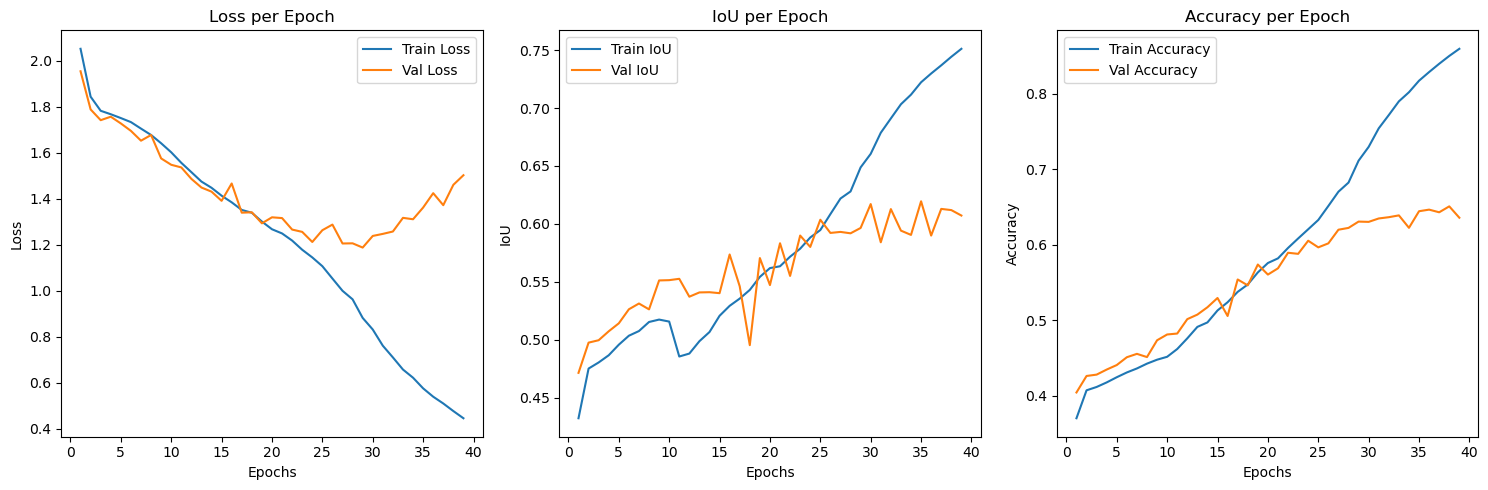

In [8]:
if __name__ == "__main__":
    main()